# MLP Regression Tests AstroCLIP

## Load the Data and crossmatch with catalog

In [1]:
import numpy as np

data = np.load('/pbs/throng/training/astroinfo2025/data/AstroCLIP_team/AstroCLIP/embeddings_all.npz')
# Check the keys of stored arrays
print(data.files)
# Access the embeddings array (replace 'arr_0' with the actual key)
test_embeddings = data['image_embeddings']  
print(test_embeddings.shape)

['cosine_similarity', 'image_embeddings', 'spectrum_embeddings', 'joint_pca', 'pca_variance', 'flux', 'wavelength', 'images', 'redshift', 'pair_id', 'targetid', 'metadata']
(12210, 1024)


### Inspects the Embeddings 

/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


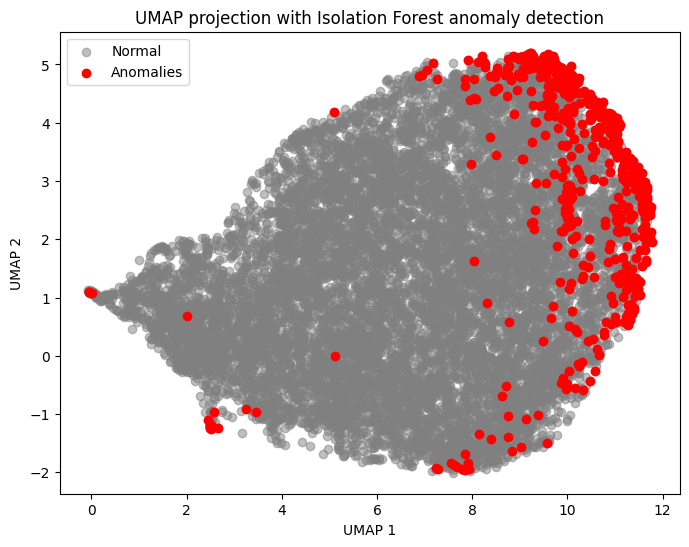

Found 611 anomalies using Isolation Forest with contamination=0.05


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.ensemble import IsolationForest

# Convert embeddings tensor to numpy array if needed
if hasattr(test_embeddings, 'cpu'):
    emb_np = test_embeddings.cpu().numpy()
else:
    emb_np = test_embeddings

# 1. Fit Isolation Forest for anomaly detection
contamination = 0.05  # 5% of data expected to be anomalies, adjust as needed
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(emb_np)

# 2. Predict anomalies: -1 is anomaly, 1 is normal
anomaly_labels = iso_forest.predict(emb_np)
anomalies = np.where(anomaly_labels == -1)[0]

# 3. Visualization with UMAP
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='gray', alpha=0.5, label='Normal')
plt.scatter(embedding_2d[anomalies, 0], embedding_2d[anomalies, 1], color='red', label='Anomalies')
plt.legend()
plt.title('UMAP projection with Isolation Forest anomaly detection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

print(f"Found {len(anomalies)} anomalies using Isolation Forest with contamination={contamination}")


### Inspects the catalog

In [3]:
from astropy.io import fits

hdulist = fits.open('/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/desi_euclid_catalog.fits')
table_data = hdulist[1].data
columns = table_data.columns   # This lists column names and formats
print(columns)
hdulist.close()


ColDefs(
    name = 'object_id'; format = 'K'; null = -9223372036854775808
    name = 'right_ascension'; format = 'D'
    name = 'declination'; format = 'D'
    name = 'segmentation_area'; format = 'K'; null = -9223372036854775808
    name = 'flux_h_sersic'; format = 'D'
    name = 'flux_vis_sersic'; format = 'D'
    name = 'ellipticity'; format = 'D'
    name = 'kron_radius'; format = 'D'
    name = 'segmentation_map_id'; format = 'K'; null = -9223372036854775808
    name = 'VIS_name'; format = '100A'
    name = 'flux_detection_total'; format = 'D'
    name = 'flux_vis_4fwhm_aper'; format = 'D'
    name = 'flux_vis_3fwhm_aper'; format = 'D'
    name = 'flux_vis_2fwhm_aper'; format = 'D'
    name = 'flux_vis_1fwhm_aper'; format = 'D'
    name = 'spurious_flag'; format = 'K'; null = -9223372036854775808
    name = 'det_quality_flag'; format = 'K'; null = -9223372036854775808
    name = 'mumax_minus_mag'; format = 'D'
    name = 'smooth_or_featured_smooth'; format = 'D'
    name = 'smoot

In [4]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from astropy.io import fits

# Custom collate function to avoid KeyError by handling keys explicitly
def custom_collate(batch):
    # Batch is a list of dicts; stack each key's data separately where possible
    collated = {}
    keys = batch[0].keys()
    for key in keys:
        # Convert each key's list of tensors/arrays into a tensor batch
        values = [item[key] for item in batch]
        # Handle tensor stacking vs other types (e.g., numbers)
        if isinstance(values[0], torch.Tensor):
            collated[key] = torch.stack(values)
        else:
            collated[key] = values
    return collated


# Load the dataset with torch formatting
dataset_path = "/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/data/"
dset = load_dataset(dataset_path, streaming=True, split="train")
dset = dset.with_format("torch")

# Setup DataLoader with custom collate function to safely batch data
dloader = DataLoader(dset, batch_size=256, collate_fn=custom_collate, drop_last=True)

# Collect object_ids from a limited number of batches to avoid memory issues
object_ids_list = []
for i, batch in enumerate(dloader):
    # batch is a dict; get 'object_id' which is a tensor of shape [batch_size]
    object_ids_list.extend(batch['object_id'].numpy())
    if (i + 1) % 50 == 0:
        print(i)
    #if i >= 10:  # e.g., first 11 batches
    #    break

object_ids_array = np.array(object_ids_list)
print(len(object_ids_array))

# Load FITS catalog and extract object_id column
with fits.open('/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/desi_euclid_catalog.fits') as hdulist:
    table_data = hdulist[1].data
    fits_object_ids = table_data['object_id']

# Convert both catalogs to pandas DataFrames for merging
df_dataset = pd.DataFrame({'object_id': object_ids_array})
df_fits = pd.DataFrame({'object_id': fits_object_ids})

# Cross-match catalogs by inner merging on 'object_id'
df_cross_matched = pd.merge(df_dataset, df_fits, on='object_id', how='inner')

print(f"Number of matched objects: {len(df_cross_matched)}")
print(df_cross_matched.head())




Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

12032
Number of matched objects: 12599
             object_id
0  2717133723668032087
1  2697025639635422031
2  2689998354648490199
3  2673429640659180447
4  2673429640659180447


In [5]:
# Create a mapping from object_id to ellipticity
parameters = table_data['ellipticity']

id_to_parameters = dict(zip(fits_object_ids, parameters))

# Add ellipticity to your cross-matched DataFrame
df_cross_matched['ellipticity'] = df_cross_matched['object_id'].map(id_to_parameters)

print(df_cross_matched[['object_id', 'ellipticity']].head())

#df_cross_matched.to_csv('df_crossmatch_ell.csv', index=False)


             object_id  ellipticity
0  2717133723668032087     0.640207
1  2697025639635422031     0.632101
2  2689998354648490199     0.224481
3  2673429640659180447     0.274814
4  2673429640659180447     0.274814


In [6]:
# Get array of matched IDs
matched_ids = df_cross_matched['object_id'].values

# Create a mapping from object_id to index in original dataset batch collection
id_to_index = {obj_id: idx for idx, obj_id in enumerate(object_ids_array)}

# Get indices of matched objects relative to dataset batches
matched_indices = [id_to_index[obj_id] for obj_id in matched_ids if obj_id in id_to_index]

# Convert to torch tensor for indexing
matched_indices_tensor = torch.tensor(matched_indices)

# Suppose embeddings is a tensor of shape [N_total_objects, embedding_dim]
# Apply index to select matched embeddings
matched_embeddings = test_embeddings[matched_indices_tensor]

print(matched_embeddings.shape)

(12599, 1024)


In [7]:
from sklearn.model_selection import train_test_split

parameters = table_data['ellipticity']

X_train, X_test, y_train, y_test = train_test_split(
    matched_embeddings, df_cross_matched['ellipticity'], test_size=0.2, random_state=42)

## MLP Regression

### MLPRegressor

In [39]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# X_train, X_test: AstroCLIP embeddings for train and test galaxies
# y_train, y_test: known physical properties

mlp = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"MLP Regression R^2 score: {score:.3f}")

MLP Regression R^2 score: -0.039


### Small MLP

Epoch [50/300], Loss: 0.4026
Epoch [100/300], Loss: 0.3336
Epoch [150/300], Loss: 0.2510
Epoch [200/300], Loss: 0.2133
Epoch [250/300], Loss: 0.1759
Epoch [300/300], Loss: 0.1534
Train R^2: 0.845
Test R^2: -0.250
Test MAE: 0.173


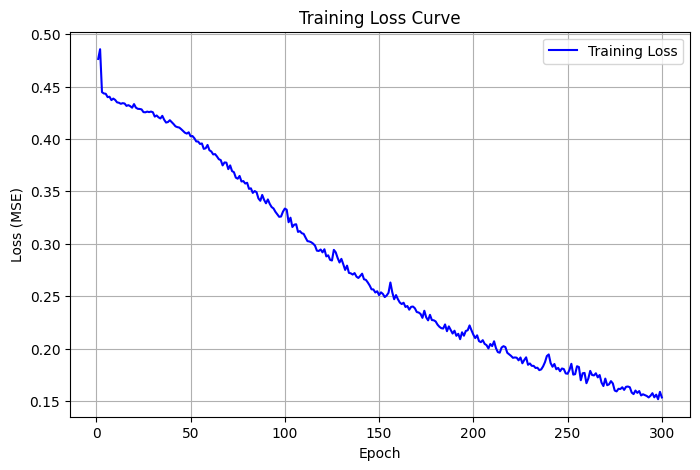

In [41]:
# Improved deeper MLP model with dropout and batch norm

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Train-test split

# Reshape target y if 1D to 2D for scaler compatibility
if y_train.ndim == 1:
    y_train = np.asarray(y_train).reshape(-1, 1)
    y_test = np.asarray(y_test).reshape(-1, 1)

# Standardize inputs and targets
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# Improved deeper MLP model with dropout and batch norm
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ImprovedMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_t.shape[1]
output_dim = y_train_t.shape[1]

model = ImprovedMLP(input_dim, output_dim)

# Optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.SmoothL1Loss()  # Huber loss

# Training

losses = []
num_epochs=300
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).numpy()
    y_pred_test = model(X_test_t).numpy()

# Inverse transform predictions and ground truth
y_pred_train_orig = scaler_y.inverse_transform(y_pred_train)
y_pred_test_orig = scaler_y.inverse_transform(y_pred_test)
y_train_orig = scaler_y.inverse_transform(y_train_scaled)
y_test_orig = scaler_y.inverse_transform(y_test_scaled)

# Compute metrics
r2_train = r2_score(y_train_orig, y_pred_train_orig)
r2_test = r2_score(y_test_orig, y_pred_test_orig)
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

print(f"Train R^2: {r2_train:.3f}")
print(f"Test R^2: {r2_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")


### Vizualisation Plots

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred arrays in original scale
def plot_true_vs_pred(y_true, y_pred, property_name="Ellipticity"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel(f"True {property_name}")
    plt.ylabel(f"Predicted {property_name}")
    plt.title("True vs Predicted AstroCLIP")
    plt.xlim(-0.1,1)
    plt.ylim(-0.1,1)
    plt.grid(True)
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_true, residuals, s=10, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("True Value")
    plt.ylabel("Residual (True - Predicted)")
    plt.title("Residuals Plot")
    plt.grid(True)
    plt.show()

def plot_distributions(y_true, y_pred):
    plt.figure(figsize=(6,4))
    plt.hist(y_true, bins=50, alpha=0.5, label="True", density=True)
    plt.hist(y_pred, bins=50, alpha=0.5, label="Predicted", density=True)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Distribution Comparison AstroCLIP")
    plt.legend()
    plt.show()


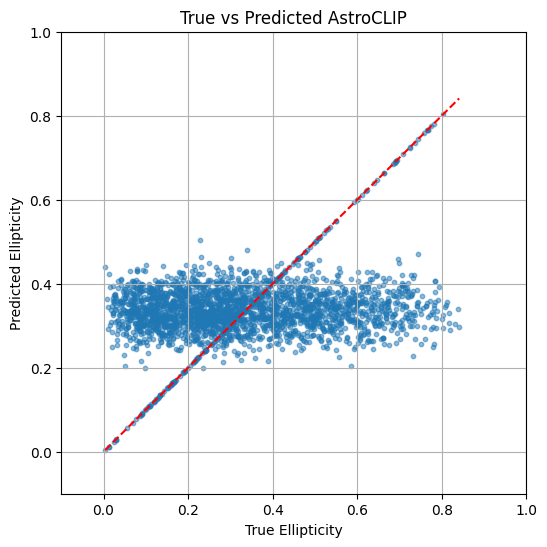

In [12]:
plot_true_vs_pred(y_test,y_pred_test)

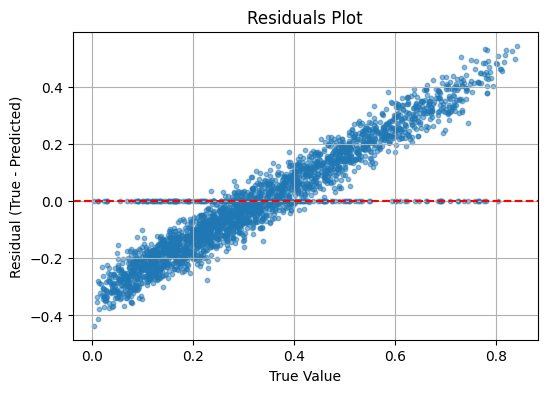

In [52]:
plot_residuals(y_test,y_pred_test)

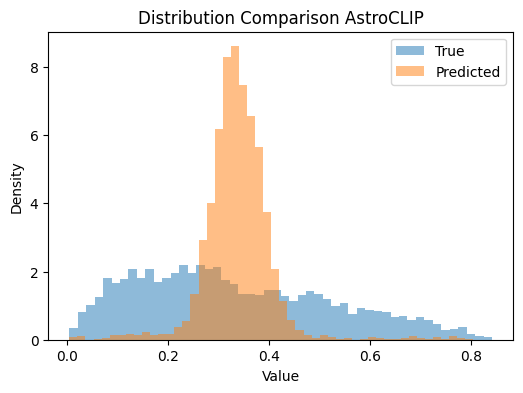

In [59]:
plot_distributions(y_test,y_pred_test)

### Percentage

In [9]:
import numpy as np

def percentage_well_predicted(y_true, y_pred, tolerance=0.1):
    """
    Calculate percentage of predictions with absolute percentage error <= tolerance.

    Parameters:
    - y_true: numpy array of true values
    - y_pred: numpy array of predicted values
    - tolerance: float, e.g., 0.1 means 10% error tolerance

    Returns:
    - percent: float, percentage (0-100) of well-predicted samples
    """
    # Avoid division by zero by adding a small epsilon (or exclude zero targets)
    epsilon = 1e-8
    ape = np.abs(y_true - y_pred) / (np.abs(y_true) + epsilon)
    well_predicted_count = np.sum(ape <= tolerance)
    percent = 100 * well_predicted_count / len(y_true)
    return percent

# Example usage
percent_10pct = percentage_well_predicted(y_test.flatten(), y_pred_test.flatten(), tolerance=0.1)
print(f"Percentage of predictions within 10% error: {percent_10pct:.2f}%")


AttributeError: 'Series' object has no attribute 'flatten'

### KNN Tests

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Initialize the KNN regressor
knn = KNeighborsRegressor(n_neighbors=20,weights='distance')

# Fit the KNN model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = knn.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_test)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.036059187223933385


In [50]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {'n_neighbors': [1, 3, 5, 7, 10, 15, 20], 'weights': ['uniform', 'distance']}

# Initialize the KNN regressor
knn = KNeighborsRegressor()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error with Grid Search: {mse}')


Best parameters: {'n_neighbors': 20, 'weights': 'distance'}
Mean Squared Error with Grid Search: 0.036059187223933385


### Another MLP Test

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
mse = criterion(y_pred_test, y_test).item()
print("MSE:", mse)


MSE: 0.03990629315376282
